# MedStock-AU: Pharmaceutical Demand Forecasting
## Module 2 — Exploratory Data Analysis (EDA)

**Author:** Amanda  
**Date:** April 2026  

---

### Overview

This notebook performs exploratory data analysis on the synthetic pharmacy demand dataset generated in Module 1.

The goals of this EDA are:
1. Understand demand distributions across locations and medications
2. Identify seasonal and weekly patterns
3. Detect anomalies and stockout events
4. Assess correlations between features
5. Prepare insights to guide LSTM model design in Module 3

---

## 1. Load Data & Basic Info

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/raw/pharmacy_demand.csv', parse_dates=['date'])

print(f"Shape          : {df.shape}")
print(f"Date range     : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Locations      : {df['location'].nunique()}")
print(f"Medications    : {df['medication'].nunique()}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
df.info()

Shape          : (105216, 16)
Date range     : 2022-01-01 → 2024-12-31
Locations      : 8
Medications    : 15
Missing values : 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105216 entries, 0 to 105215
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            105216 non-null  datetime64[ns]
 1   location        105216 non-null  object        
 2   location_type   105216 non-null  object        
 3   suburb          105216 non-null  object        
 4   medication      105216 non-null  object        
 5   category        105216 non-null  object        
 6   demand_units    105216 non-null  int64         
 7   is_weekend      105216 non-null  int64         
 8   month           105216 non-null  int64         
 9   quarter         105216 non-null  int64         
 10  day_of_week     105216 non-null  int64         
 11  day_of_year     105216 non-null  int64         
 12  year        

## 2. Descriptive Statistics

In [18]:
print("=== Overall Demand Statistics ===")
print(df['demand_units'].describe().round(2))

print("\n=== Demand by Location Type ===")
print(df.groupby('location_type')['demand_units'].describe().round(2))

print("\n=== Stockout Rate (demand = 0) ===")
stockout = df[df['demand_units'] == 0]
print(f"Total stockout records : {len(stockout):,}")
print(f"Stockout rate          : {len(stockout)/len(df)*100:.2f}%")
print()
print(df.groupby('location')['demand_units'].apply(
    lambda x: f"{(x == 0).sum()} stockouts ({(x == 0).mean()*100:.1f}%)"
))

=== Overall Demand Statistics ===
count    105216.00
mean         95.26
std          82.46
min           0.00
25%          50.00
50%          72.00
75%         115.00
max        3259.00
Name: demand_units, dtype: float64

=== Demand by Location Type ===
                 count    mean    std  min   25%   50%    75%     max
location_type                                                        
hospital       52608.0  118.37  98.93  0.0  61.0  95.0  144.0  3259.0
retail         52608.0   72.16  52.38  0.0  44.0  59.0   82.0  1330.0

=== Stockout Rate (demand = 0) ===
Total stockout records : 1,072
Stockout rate          : 1.02%

location
Chemist Warehouse Epping             119 stockouts (0.9%)
Chemist Warehouse Sydney CBD         123 stockouts (0.9%)
Priceline Pharmacy Pitt Street       133 stockouts (1.0%)
Prince of Wales Hospital Pharmacy    139 stockouts (1.1%)
RPA Hospital Pharmacy                136 stockouts (1.0%)
St Vincent's Hospital Pharmacy       155 stockouts (1.2%)
TerryWhite

## 3. Demand Distribution

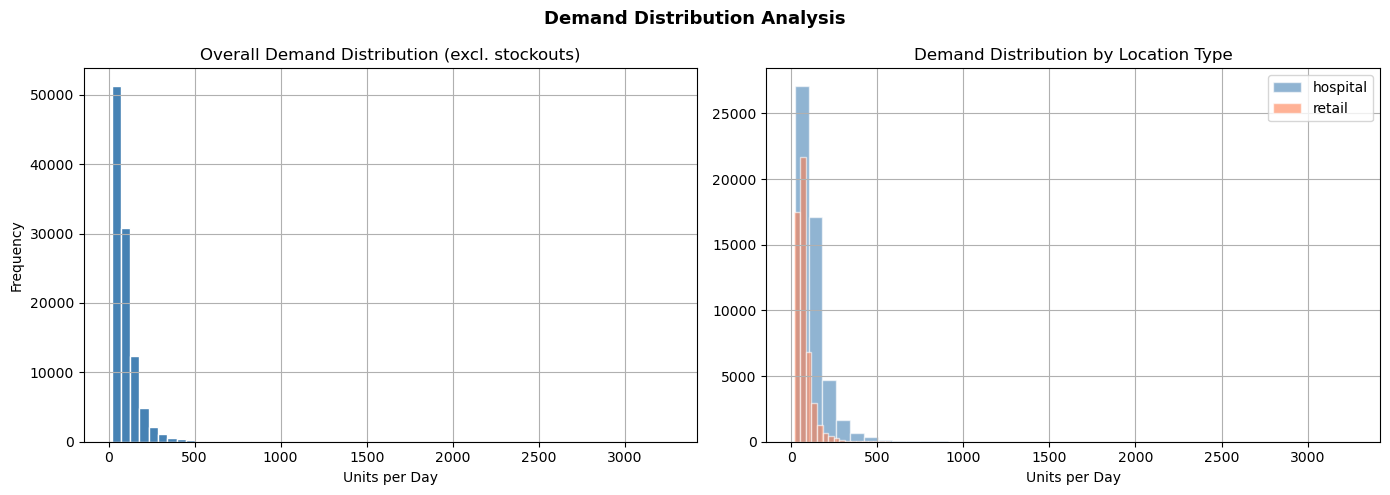

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Demand Distribution Analysis', fontsize=13, fontweight='bold')

# Overall distribution
ax1 = axes[0]
df[df['demand_units'] > 0]['demand_units'].hist(bins=60, ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Overall Demand Distribution (excl. stockouts)')
ax1.set_xlabel('Units per Day')
ax1.set_ylabel('Frequency')

# By location type
ax2 = axes[1]
for loc_type, color in zip(['hospital', 'retail'], ['steelblue', 'coral']):
    subset = df[(df['location_type'] == loc_type) & (df['demand_units'] > 0)]
    subset['demand_units'].hist(bins=40, ax=ax2, alpha=0.6, label=loc_type, color=color, edgecolor='white')
ax2.set_title('Demand Distribution by Location Type')
ax2.set_xlabel('Units per Day')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/02_demand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Seasonal Patterns

Australian seasons:
- **Summer**: December – February
- **Autumn**: March – May
- **Winter**: June – August ← peak for respiratory/analgesic medications
- **Spring**: September – November

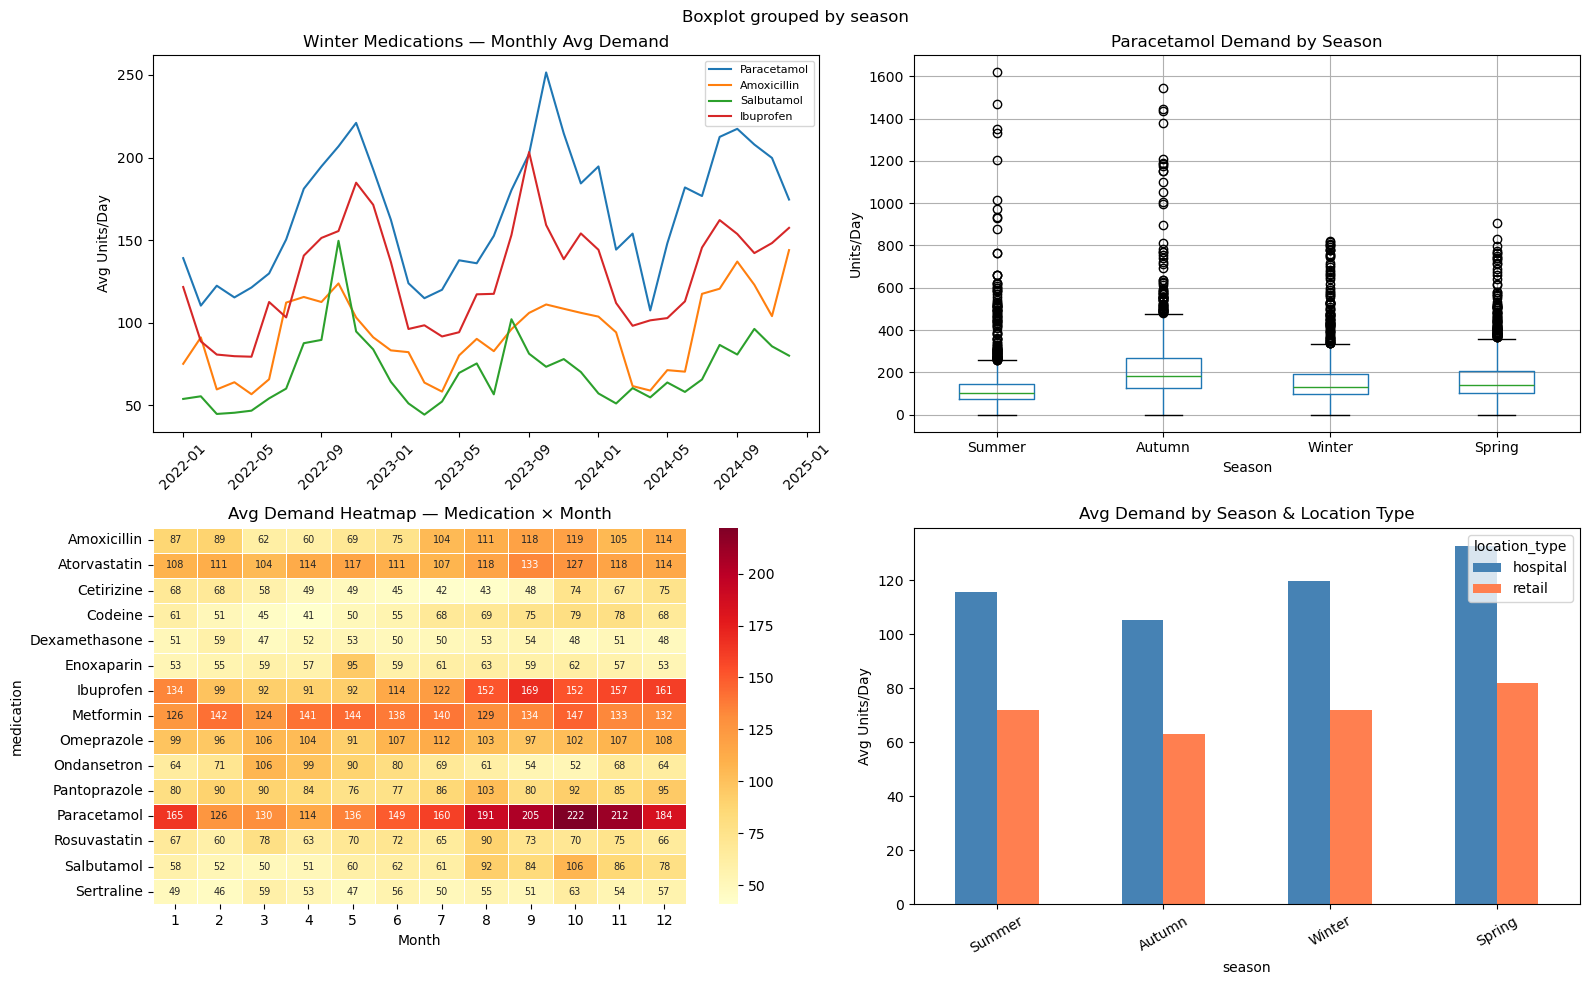

In [20]:
# Add season column
def get_season(month):
    if month in [12, 1, 2]:   return 'Summer'
    elif month in [3, 4, 5]:  return 'Autumn'
    elif month in [6, 7, 8]:  return 'Winter'
    else:                      return 'Spring'

df['season'] = df['month'].apply(get_season)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Seasonal Demand Patterns — Sydney Pharmacies', fontsize=13, fontweight='bold')

# Plot 1: Monthly avg demand — winter medications
ax1 = axes[0, 0]
winter_meds = ['Paracetamol', 'Amoxicillin', 'Salbutamol', 'Ibuprofen']
monthly = df.groupby(['medication', df['date'].dt.to_period('M')])['demand_units'].mean().reset_index()
monthly['date'] = monthly['date'].dt.to_timestamp()
for med in winter_meds:
    s = monthly[monthly['medication'] == med]
    ax1.plot(s['date'], s['demand_units'], label=med, linewidth=1.5)
ax1.set_title('Winter Medications — Monthly Avg Demand')
ax1.set_ylabel('Avg Units/Day')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Season boxplot — Paracetamol
ax2 = axes[0, 1]
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
para = df[df['medication'] == 'Paracetamol']
para.boxplot(column='demand_units', by='season', ax=ax2,
             positions=[season_order.index(s) for s in season_order])
ax2.set_title('Paracetamol Demand by Season')
ax2.set_xlabel('Season')
ax2.set_ylabel('Units/Day')
plt.sca(ax2)
plt.xticks(range(4), season_order)

# Plot 3: Monthly heatmap — all medications
ax3 = axes[1, 0]
heatmap_data = df.groupby(['medication', 'month'])['demand_units'].mean().unstack()
sns.heatmap(heatmap_data, ax=ax3, cmap='YlOrRd', linewidths=0.5, fmt='.0f', annot=True, annot_kws={'size': 7})
ax3.set_title('Avg Demand Heatmap — Medication × Month')
ax3.set_xlabel('Month')

# Plot 4: Season avg by location type
ax4 = axes[1, 1]
season_loc = df.groupby(['season', 'location_type'])['demand_units'].mean().unstack()
season_loc = season_loc.loc[season_order]
season_loc.plot(kind='bar', ax=ax4, color=['steelblue', 'coral'])
ax4.set_title('Avg Demand by Season & Location Type')
ax4.set_ylabel('Avg Units/Day')
ax4.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/02_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Weekly Patterns

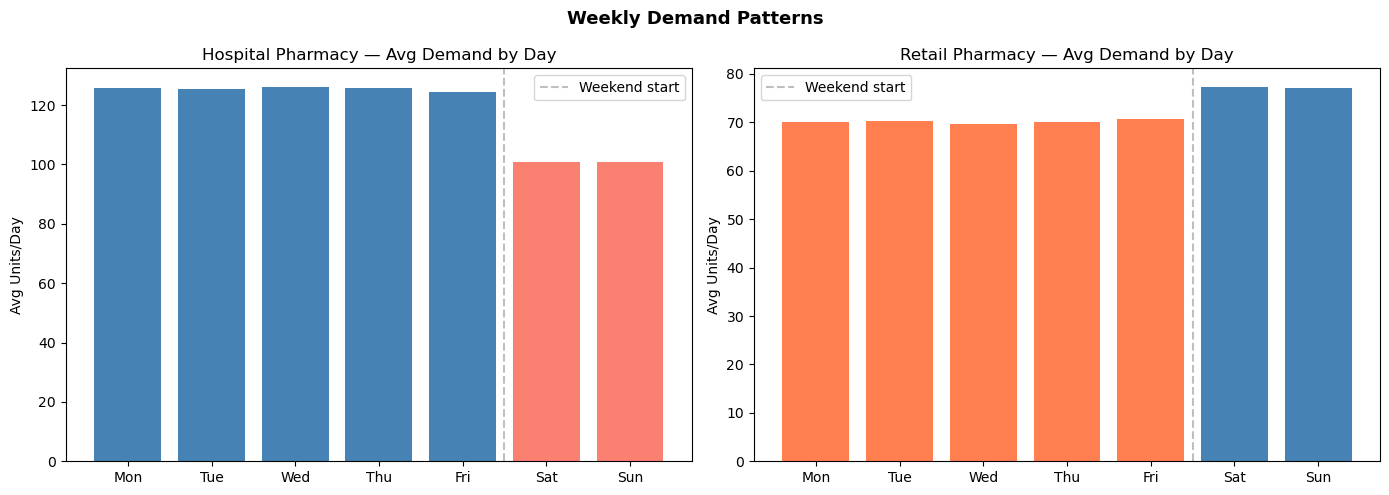

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Demand Patterns', fontsize=13, fontweight='bold')

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Hospital weekly pattern
ax1 = axes[0]
hosp = df[df['location_type'] == 'hospital']
weekly_hosp = hosp.groupby('day_of_week')['demand_units'].mean()
ax1.bar(day_labels, weekly_hosp.values, color=['steelblue']*5 + ['salmon']*2)
ax1.set_title('Hospital Pharmacy — Avg Demand by Day')
ax1.set_ylabel('Avg Units/Day')
ax1.axvline(x=4.5, color='grey', linestyle='--', alpha=0.5, label='Weekend start')
ax1.legend()

# Retail weekly pattern
ax2 = axes[1]
retail = df[df['location_type'] == 'retail']
weekly_retail = retail.groupby('day_of_week')['demand_units'].mean()
ax2.bar(day_labels, weekly_retail.values, color=['coral']*5 + ['steelblue']*2)
ax2.set_title('Retail Pharmacy — Avg Demand by Day')
ax2.set_ylabel('Avg Units/Day')
ax2.axvline(x=4.5, color='grey', linestyle='--', alpha=0.5, label='Weekend start')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/02_weekly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Anomaly Detection Preview

Identifying demand spikes that exceed 2 standard deviations from the rolling mean.  
These will be formally modelled using Isolation Forest in Module 4.

Anomaly rate (>2 std dev): 3.98%
Total anomaly records    : 4,189


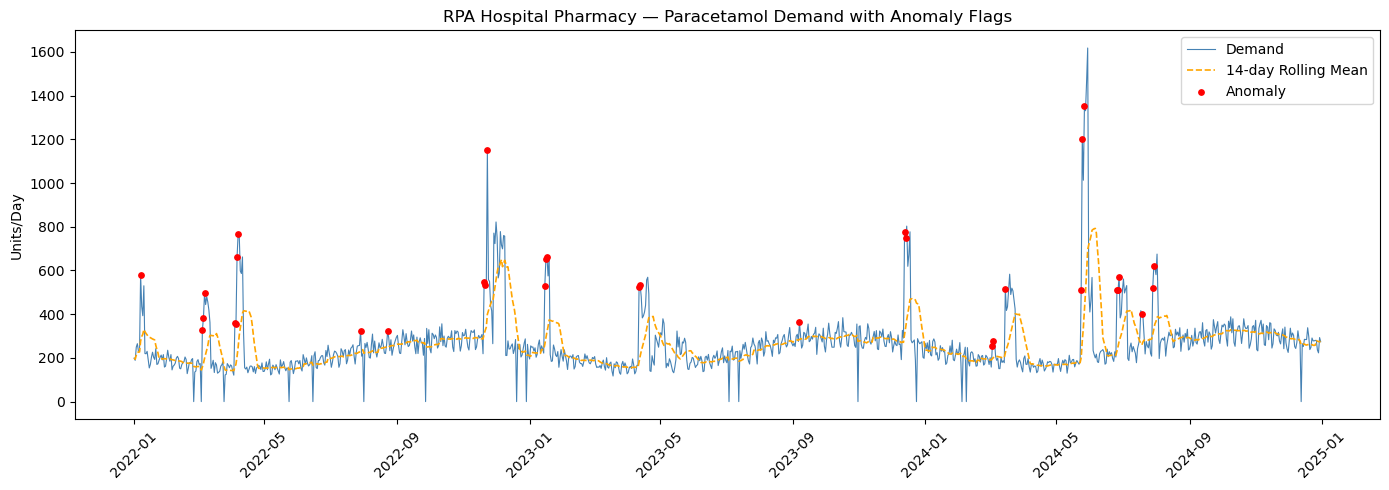

In [22]:
# Calculate rolling stats per medication-location pair
df_sorted = df.sort_values(['location', 'medication', 'date']).copy()
df_sorted['rolling_mean'] = df_sorted.groupby(['location', 'medication'])['demand_units'].transform(
    lambda x: x.rolling(window=14, min_periods=1).mean()
)
df_sorted['rolling_std'] = df_sorted.groupby(['location', 'medication'])['demand_units'].transform(
    lambda x: x.rolling(window=14, min_periods=1).std().fillna(0)
)
df_sorted['is_anomaly'] = (
    df_sorted['demand_units'] > df_sorted['rolling_mean'] + 2 * df_sorted['rolling_std']
).astype(int)

anomaly_rate = df_sorted['is_anomaly'].mean() * 100
print(f"Anomaly rate (>2 std dev): {anomaly_rate:.2f}%")
print(f"Total anomaly records    : {df_sorted['is_anomaly'].sum():,}")

# Visualise anomalies for RPA + Paracetamol
fig, ax = plt.subplots(figsize=(14, 5))
rpa_para = df_sorted[
    (df_sorted['location'] == 'RPA Hospital Pharmacy') &
    (df_sorted['medication'] == 'Paracetamol')
].copy()

ax.plot(rpa_para['date'], rpa_para['demand_units'], color='steelblue', linewidth=0.8, label='Demand')
ax.plot(rpa_para['date'], rpa_para['rolling_mean'], color='orange', linewidth=1.2, linestyle='--', label='14-day Rolling Mean')
anomalies = rpa_para[rpa_para['is_anomaly'] == 1]
ax.scatter(anomalies['date'], anomalies['demand_units'], color='red', s=15, zorder=5, label='Anomaly')

ax.set_title('RPA Hospital Pharmacy — Paracetamol Demand with Anomaly Flags')
ax.set_ylabel('Units/Day')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/02_anomaly_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Year-on-Year Growth Trend

=== Year-on-Year Average Demand ===
location_type  hospital  retail
year                           
2022             113.28   67.26
2023             118.36   71.86
2024             123.45   77.35

Hospital demand growth 2022→2024 : +9.0%
Retail demand growth   2022→2024 : +15.0%


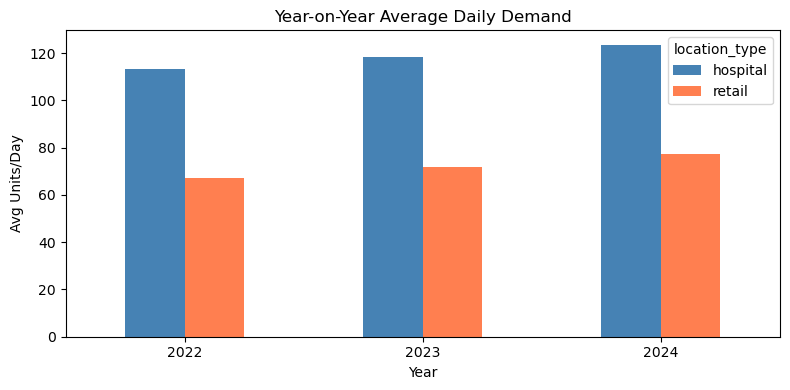

In [23]:
yearly = df.groupby(['year', 'location_type'])['demand_units'].mean().unstack()
print("=== Year-on-Year Average Demand ===")
print(yearly.round(2))
print()

growth_hosp   = (yearly.loc[2024, 'hospital'] / yearly.loc[2022, 'hospital'] - 1) * 100
growth_retail = (yearly.loc[2024, 'retail']   / yearly.loc[2022, 'retail']   - 1) * 100
print(f"Hospital demand growth 2022→2024 : +{growth_hosp:.1f}%")
print(f"Retail demand growth   2022→2024 : +{growth_retail:.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
yearly.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Year-on-Year Average Daily Demand')
ax.set_ylabel('Avg Units/Day')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../reports/02_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Processed Data

In [24]:
# Save enriched dataset with season and anomaly flag
df_processed = df_sorted.copy()
output_path = '../data/processed/pharmacy_demand_processed.csv'
df_processed.to_csv(output_path, index=False)

print(f"Processed dataset saved : {output_path}")
print(f"Shape                   : {df_processed.shape}")
print(f"New columns added       : season, rolling_mean, rolling_std, is_anomaly")

Processed dataset saved : ../data/processed/pharmacy_demand_processed.csv
Shape                   : (105216, 20)
New columns added       : season, rolling_mean, rolling_std, is_anomaly


## Summary

| Analysis | Key Finding |
|----------|-------------|
| Demand distribution | Right-skewed; hospital avg 118 units/day vs retail 72 units/day |
| Seasonal pattern | Clear winter peak for analgesics, antibiotics, respiratory medications; Paracetamol peaks at 222 units in October |
| Weekly pattern | Hospital: weekends −20%; Retail: weekends +10% |
| Anomaly rate | 3.98% of records flagged as demand spikes (>2 std dev from rolling mean) |
| Growth trend | Hospital +9.0%, Retail +15.0% over 2022–2024 |
| Stockout rate | 1.02% of records (by design, simulating real supply disruptions) |

---
*Next: Module 3 — Demand Forecasting (Prophet → XGBoost → LSTM)*